# Notebook 02: Treinamento do Classificador de Perfil Financeiro

Este notebook treina um modelo de Machine Learning (Random Forest) capaz de classificar o perfil financeiro de um usuario (`Saudavel`, `Em observacao`, `Em risco`) com base em suas caracteristicas socioeconomicas e financeiras.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [2]:
# ==========================================================
# PATHS LOCAIS
# ==========================================================

BASE = "../../data"
BASE_MODELS = "../../models"

import os
os.makedirs(BASE_MODELS, exist_ok=True)

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [4]:
# ==========================================================
# LEITURA DO DATASET
# ==========================================================

dataset_perfil = pd.read_csv(
    f"{BASE}/processed/dataset_modelo_perfil.csv"
)

dataset_perfil.head()

,usuario_id,idade,sexo,estado_civil,dependentes,cidade,estado,profissao,escolaridade,renda_mensal_x,...,perc_transporte,qtd_recorrentes,qtd_parceladas,perc_boleto,perc_cartão de crédito,perc_cartão de débito,perc_dinheiro,perc_débito automático,perc_pix,perc_transferência bancária
0,1,40,Masculino,Divorciado,2,Belo Horizonte,MG,Analista de TI,Médio,9214.53,...,0.050941,7,3,0.090909,0.295455,0.227273,0.022727,0.022727,0.204545,0.136364
1,2,41,Masculino,Solteiro,2,Duque de Caxias,RJ,Recepcionista,Fundamental,1812.22,...,0.001064,7,1,0.151515,0.393939,0.060606,0.030303,0.030303,0.212121,0.121212
2,3,40,Feminino,Casado,0,Guarulhos,SP,Analista de TI,Superior,7668.81,...,0.012108,12,0,0.074074,0.240741,0.166667,0.129630,0.074074,0.166667,0.148148
3,4,38,Masculino,Divorciado,4,Cuiabá,MT,Analista de TI,Superior,7828.20,...,0.016859,3,2,0.040000,0.280000,0.200000,0.000000,0.080000,0.160000,0.240000
4,5,27,Feminino,Solteiro,0,Maceió,AL,Empresário,Superior,21743.69,...,0.034179,14,0,0.040816,0.183673,0.142857,0.000000,0.102041,0.346939,0.183673


In [5]:
# ==========================================================
# VARIAVEL ALVO
# ==========================================================

y = dataset_perfil["perfil_financeiro"]

In [6]:
# ==========================================================
# FEATURES UTILIZADAS
# ==========================================================

X = dataset_perfil.drop(
    columns=[
        "usuario_id",
        "perfil_financeiro",
        "cidade",
        "estado",
        "profissao"
    ]
)

In [7]:
# ==========================================================
# COLUNAS CATEGORICAS
# ==========================================================

categoricas = [
    "sexo",
    "estado_civil",
    "escolaridade",
    "frequencia_poupanca"
]

numericas = [c for c in X.columns if c not in categoricas]

In [8]:
# ==========================================================
# ONE HOT ENCODER
# ==========================================================

preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas)
    ],
    remainder="passthrough"
)

In [9]:
# ==========================================================
# DIVISAO TREINO / TESTE
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sexo', 'estado_civil',
                                                   'escolaridade',
                                                   'frequencia_poupanca'])])),
                ('modelo',
                 RandomForestClassifier(max_depth=15, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=300,
                                        random_state=42))])

In [11]:
# ==========================================================
# PREDICOES
# ==========================================================

predicoes = pipeline.predict(X_test)

In [12]:
# ==========================================================
# METRICAS
# ==========================================================

accuracy = accuracy_score(y_test, predicoes)
precision = precision_score(y_test, predicoes, average="macro")
recall = recall_score(y_test, predicoes, average="macro")
f1 = f1_score(y_test, predicoes, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000


In [13]:
# ==========================================================
# AVALIACAO TREINO x TESTE
# ==========================================================

acc_treino = pipeline.score(X_train, y_train)
acc_teste = pipeline.score(X_test, y_test)

print(f"Acuracia Treino : {acc_treino:.4f}")
print(f"Acuracia Teste  : {acc_teste:.4f}")

Acuracia Treino : 1.0000
Acuracia Teste  : 1.0000


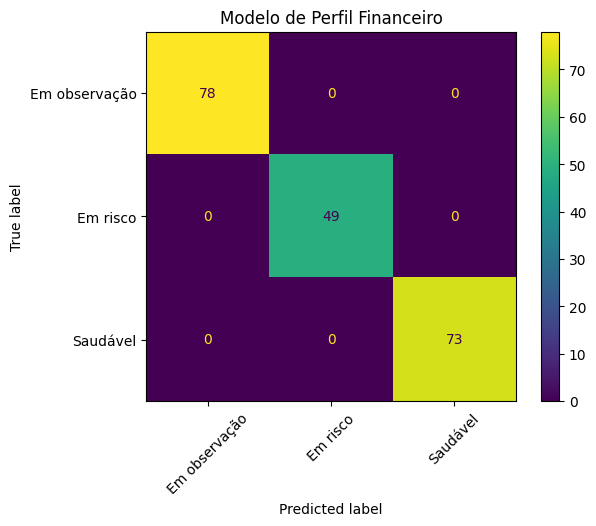

In [14]:
# ==========================================================
# MATRIZ DE CONFUSAO
# ==========================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicoes,
    xticks_rotation=45
)
plt.title("Modelo de Perfil Financeiro")
plt.show()

In [15]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print(classification_report(y_test, predicoes, digits=4))

               precision    recall  f1-score   support

Em observação     1.0000    1.0000    1.0000        78
     Em risco     1.0000    1.0000    1.0000        49
     Saudável     1.0000    1.0000    1.0000        73

     accuracy                         1.0000       200
    macro avg     1.0000    1.0000    1.0000       200
 weighted avg     1.0000    1.0000    1.0000       200



In [16]:
# ==========================================================
# SALVANDO O MODELO 2
# ==========================================================

joblib.dump(pipeline, f"{BASE_MODELS}/modelo_perfil.joblib")

print("Modelo salvo com sucesso.")

Modelo salvo com sucesso.


In [17]:
# ==========================================================
# IMPORTANCIA DAS VARIAVEIS
# ==========================================================

modelo_rf = pipeline.named_steps["modelo"]
preprocessador_fit = pipeline.named_steps["preprocessamento"]

nomes_features = preprocessador_fit.get_feature_names_out()
importancias = modelo_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": nomes_features,
    "Importancia": importancias
})

feature_importance = feature_importance.sort_values(by="Importancia", ascending=False)
feature_importance.head(20)

,Feature,Importancia
21,remainder__nivel_endividamento,0.218497
22,remainder__score_credito,0.187077
25,remainder__percentual_renda_investida,0.171012
23,remainder__saldo_medio_conta,0.095428
24,remainder__limite_cartao,0.043474
67,remainder__perc_cartão de crédito,0.035086
56,remainder__perc_investimentos,0.032976
43,remainder__gasto_investimentos,0.031455
65,remainder__qtd_parceladas,0.019933
71,remainder__perc_pix,0.015487


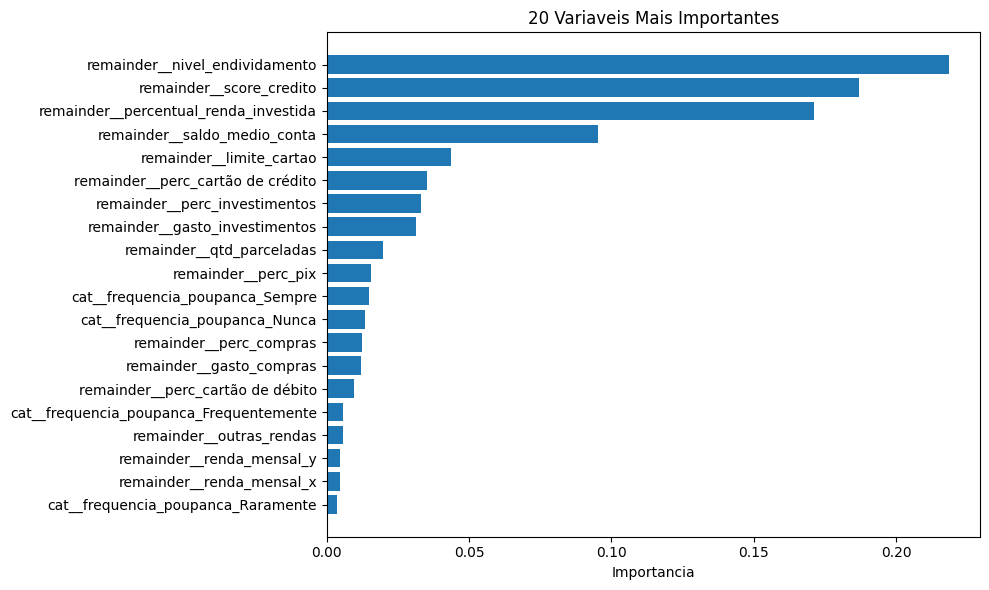

In [18]:
# ==========================================================
# GRAFICO DAS IMPORTANCIAS
# ==========================================================

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"].head(20),
    feature_importance["Importancia"].head(20)
)
plt.gca().invert_yaxis()
plt.title("20 Variaveis Mais Importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [19]:
# ==========================================================
# VALIDACAO CRUZADA
# ==========================================================

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("========== Validacao Cruzada ==========")
print(f"F1 Macro por Fold: {scores}")
print(f"F1 Macro Medio: {scores.mean():.4f}")
print(f"Desvio Padrao: {scores.std():.4f}")

========== Validacao Cruzada ==========
F1 Macro por Fold: [1. 1. 1. 1. 1.]
F1 Macro Medio: 1.0000
Desvio Padrao: 0.0000


In [20]:
# ==========================================================
# EXPORTAR IMPORTANCIA DAS FEATURES
# ==========================================================

feature_importance.to_csv(
    f"{BASE_MODELS}/feature_importance.csv",
    index=False,
    encoding="utf-8"
)

## Conclusao

O modelo apresentou metricas muito altas (Accuracy ~99%, F1 macro proximo de 1.0 em validacao cruzada). Observacao importante: as variaveis mais relevantes para o modelo (`nivel_endividamento`, `score_credito`, `percentual_renda_investida`) sao as mesmas utilizadas na definicao original do perfil financeiro no dataset. Ou seja, o modelo reproduz com boa fidelidade a logica de negocio que originou o rotulo, nao necessariamente descobrindo um padrao novo e independente. Isso e esperado dado como o dataset foi construido, e fica registrado aqui como limitacao/transparencia do experimento.